# ML Pipelines Playbook

## Business Context

Customer churn refers to customers who discontinue a service or stop doing business with a company.

Predicting churn enables businesses to proactively retain customers through targeted interventions such as discounts, support outreach, and contract incentives.

Reducing churn can significantly improve customer retention, customer lifetime value, and revenue stability.

---

## Objective

Build reliable and reusable machine learning preprocessing workflows for customer churn prediction.

The focus of this notebook is not model performance, but designing preprocessing systems that can be consistently applied during training and inference.

---

## Business Question

How can we transform raw customer data into a format suitable for machine learning while ensuring consistency, maintainability, and reproducibility?

---

## Notebook Scope

This notebook focuses on:

- handling mixed-type datasets
- preprocessing numerical features
- preprocessing categorical features
- managing missing values
- encoding categorical variables
- scaling numerical variables
- building reusable preprocessing workflows
- understanding ColumnTransformer

Model training, cross-validation, hyperparameter tuning, and model selection will be covered in later sections of the ML Pipelines playbook.

---

## Workflow Engineering Mindset

Throughout this notebook, we will continuously ask:

> How can we ensure that the same preprocessing logic is applied every time the data is used?

The goal is not simply to clean data, but to build preprocessing workflows that are reusable, maintainable, and suitable for real-world machine learning systems.

## Imports

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd

# Local modules
from ml_playbook.config import DATA_DIR, RANDOM_STATE
from ml_playbook.evaluation.metrics import evaluate_classification_model
from ml_playbook.evaluation.comparison import compare_classification_metrics
from ml_playbook.visualization.classification_plots import plot_confusion_matrix

# Scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

## Configuration

In [2]:
# Constants
TARGET_COL = "Churn"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "customer_churn.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Data Loading and Initial Inspection

### Dataset Overview

The dataset contains customer demographic, service usage, billing, and account information along with a binary churn indicator.

Each row represents a unique customer.

### Initial Dataset Inspection

In this section, we load the dataset and perform a preliminary inspection to understand its size, structure, and feature types before designing preprocessing workflows.

### Feature Summary

The dataset contains the following features:

- `gender` – customer gender
- `SeniorCitizen` – senior citizen indicator
- `tenure` – number of months with the company
- `MonthlyCharges` – monthly service charges
- `TotalCharges` – total amount billed to the customer
- `InternetService` – internet service type
- `Contract` – customer contract type
- `PaymentMethod` – payment method used
- `Churn` – customer churn indicator

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print(f"Shape: {df.shape}")

Shape: (1200, 9)


In [4]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1200 non-null   object 
 1   SeniorCitizen    1200 non-null   int64  
 2   tenure           1200 non-null   int64  
 3   MonthlyCharges   1200 non-null   float64
 4   TotalCharges     1086 non-null   float64
 5   InternetService  1103 non-null   object 
 6   Contract         1200 non-null   object 
 7   PaymentMethod    1120 non-null   object 
 8   Churn            1200 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 84.5+ KB


### Observations

- The dataset contains a mix of numerical and categorical features.
- Missing values are present in both numerical and categorical columns.
- Different feature types require different preprocessing strategies.
- The dataset is well suited for demonstrating ColumnTransformer and reusable preprocessing workflows.
- A preprocessing system must ensure that all feature transformations are applied consistently across future datasets.

### Dataset Structure and Summary Statistics

In [5]:
feature_columns = [
    col for col in df.columns
    if col != TARGET_COL
]

### Feature Groups

Identify numerical and categorical features so that appropriate preprocessing workflows can be applied to each feature type.

In [6]:
# Features treated as categorical despite numeric storage
categorical_overrides = ["SeniorCitizen"]

# Numerical features
numerical_features = df[feature_columns].select_dtypes(
    include=np.number
).columns.tolist()

numerical_features = [
    col
    for col in numerical_features
    if col not in categorical_overrides
]

# Categorical features
categorical_features = df[feature_columns].select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_features.extend(
    categorical_overrides
)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'InternetService', 'Contract', 'PaymentMethod', 'SeniorCitizen']


### Numerical Features

Review numerical feature characteristics to understand potential preprocessing requirements such as scaling, missing value handling, and data quality issues.

In [7]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,1200.000000,1200.000000,1086.000000
mean,35.768333,71.536025,2542.810138
std,20.800927,29.009536,1940.867966
min,1.000000,18.000000,-451.660000
25%,17.000000,51.317500,1008.590000
50%,35.000000,71.170000,2199.740000
75%,54.000000,90.860000,3714.115000
max,72.000000,150.000000,9820.930000


### Categorical Features

Review categorical feature characteristics to understand category cardinality and potential encoding requirements.

In [8]:
df[categorical_features].describe(include="all")

,gender,InternetService,Contract,PaymentMethod,SeniorCitizen
count,1200,1103,1200,1120,1200.000000
unique,2,3,3,4,NaN
top,Female,Fiber optic,Month-to-month,Mailed check,NaN
freq,604,493,626,288,NaN
mean,NaN,NaN,NaN,NaN,0.155833
std,NaN,NaN,NaN,NaN,0.362848
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,0.000000


### Observations

- The dataset contains both numerical and categorical features, requiring different preprocessing strategies.
- Numerical features exist on different scales and may require scaling before model training.
- Categorical features have relatively low cardinality and are suitable for standard encoding approaches.
- Missing values are present in both numerical and categorical columns.
- Data quality issues are visible (e.g., negative values in TotalCharges), reinforcing the need for systematic preprocessing.
- Feature groups have been defined and will be used to construct reusable preprocessing workflows.

## Target Variable Analysis

The target variable is:

- `Churn`
    - `1` → Customer churned
    - `0` → Customer retained

In [9]:
target_counts = df[TARGET_COL].value_counts()

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": (
        target_counts / len(df) * 100
    ).round(2)
})

target_summary

,Count,Percentage
Churn,,
0,656,54.67
1,544,45.33


### Observations

- Both churn classes are represented in the dataset.
- No severe class imbalance is observed.
- The target distribution will be revisited during model evaluation and workflow validation.

## Missing Value Analysis

In [10]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean()* 100
        ).round(2)
})

missing_summary = (
    missing_summary
    .loc[missing_summary["Missing_Count"] > 0]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
TotalCharges,114,9.50
InternetService,97,8.08
PaymentMethod,80,6.67


### Observations

- Missing values are present in three features: `TotalCharges`, `InternetService`, and `PaymentMethod`.
- Missing values occur in both numerical and categorical feature groups.
- Missing value handling must be incorporated into the preprocessing workflow before model training.
- Different feature types may require different imputation strategies.
- Manual handling of missing values can become difficult to maintain as datasets and workflows grow.

## Duplicate Record Analysis

In [11]:
duplicate_count = df.duplicated().sum()
duplicate_pct = df.duplicated().mean() * 100

print(f"Number of rows: {len(df):,}")
print(f"Number of duplicates: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

Number of rows: 1,200
Number of duplicates: 0
Duplicate percentage: 0.00%


### Observations

- No duplicate records were identified in the dataset.
- Duplicate-related data quality issues are not a concern for this analysis.
- Duplicate validation remains an important part of the initial dataset assessment process.

## Designing Reusable Preprocessing Workflows

### Why Mixed-Type Preprocessing Matters

Real-world datasets rarely contain a single feature type.

In this dataset:
- numerical features contain continuous values such as tenure and billing information
- categorical features contain labels such as contract type and payment method

Different feature types often require different preprocessing strategies.

For example:
- numerical features may require missing value imputation and scaling
- categorical features may require missing value imputation and encoding

A reliable machine learning workflow should apply the correct preprocessing strategy to each feature type while maintaining consistency across training and inference.

---

### The Problem with Manual Preprocessing

As datasets grow, preprocessing often involves multiple steps such as:

1. imputing numerical features
2. scaling numerical features
3. imputing categorical features
4. encoding categorical features

Managing these transformations manually can make workflows difficult to maintain and prone to errors.

A more reliable approach is to organize preprocessing steps into reusable workflows that can be applied consistently across training and inference.

### Building a Numerical Preprocessing Workflow

Numerical features require both missing value handling and feature scaling.

These operations are applied sequentially using a Pipeline, allowing multiple preprocessing steps to be organized into a reusable workflow.

In [12]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

### Observations

- Missing values will be imputed using the median.
- Numerical features will be standardized to a common scale.
- Multiple preprocessing steps have been organized into a reusable workflow.

### Building a Categorical Preprocessing Workflow

Categorical features require missing value handling followed by encoding.

These operations are grouped into a separate preprocessing workflow for categorical variables.

In [13]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

### Observations

- Missing categorical values will be imputed using the most frequent category.
- Categorical variables will be converted into numerical representations using one-hot encoding.
- Unknown categories encountered during inference will be handled safely.

### Combining Workflows with ColumnTransformer

Different feature groups often require different preprocessing strategies.

ColumnTransformer enables multiple preprocessing workflows to be applied to the appropriate columns while treating the entire dataset as a single preprocessing system.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

### Observations

- Numerical and categorical preprocessing have been separated into independent workflows.
- ColumnTransformer combines these workflows into a single reusable preprocessing system.
- Feature-specific preprocessing logic no longer needs to be managed manually.
- Additional preprocessing workflows can be incorporated without changing the overall design.

### Workflow Architecture

```text
                Raw Dataset
                      │
        ┌─────────────┴─────────────┐
        │                           │
Numerical Features          Categorical Features
        │                           │
Numerical Pipeline          Categorical Pipeline
        │                           │
        └─────────────┬─────────────┘
                      │
              ColumnTransformer
                      │
              Processed Features
```

### Applying the Preprocessing Workflow

In [15]:
X = df.drop(columns=TARGET_COL, axis=1)

print(f"Shape X: {X.shape}")

Shape X: (1200, 8)


In [16]:
X_processed = preprocessor.fit_transform(X)

print(f"Shape X_processed: {X_processed.shape}")
print(f"Type X_processed: {type(X_processed)}")

Shape X_processed: (1200, 17)
Type X_processed: <class 'numpy.ndarray'>


### Inspecting the Transformed Features

The transformed output no longer preserves the original DataFrame structure.

Feature names generated by ColumnTransformer can be recovered using `get_feature_names_out()` to improve interpretability and debugging.

In [17]:
X_processed_df = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

X_processed_df.head()

,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Female,cat__gender_Male,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaymentMethod_Bank transfer,cat__PaymentMethod_Credit card,cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check,cat__SeniorCitizen_0,cat__SeniorCitizen_1
0,0.780659,-0.754067,0.144504,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.998849,-1.626903,-1.080033,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.742556,-0.328513,0.906018,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.213513,-0.740618,0.438650,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.710280,1.744774,-0.109231,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


### Observations

- The entire dataset can now be transformed using a single preprocessing object.
- Numerical and categorical transformations are applied automatically.
- The transformed output can now serve as input to downstream machine learning models.
- Feature names produced by the preprocessing workflow can be inspected for debugging and interpretability.

### Why ColumnTransformer Matters in Production

ColumnTransformer provides a structured way to apply different preprocessing workflows to different feature groups.

Compared with manually managing transformations, it:

- improves maintainability
- reduces implementation errors
- keeps preprocessing logic organized
- ensures consistent transformations during training and inference

These advantages become increasingly important as machine learning systems grow in complexity.

## Key Takeaways

- Real-world datasets often contain mixed feature types.
- Different feature groups require different preprocessing strategies.
- Multiple preprocessing steps can be organized into reusable workflows using Pipeline.
- ColumnTransformer enables different preprocessing workflows to be applied to different feature groups.
- Preprocessing logic should be treated as part of the machine learning system rather than isolated code snippets.
- Organizing preprocessing workflows improves maintainability and consistency.
- The same preprocessing system can later be reused consistently during model training and inference.

## Building End-to-End Training Workflows

### Why Combine Preprocessing and Modeling?

Machine learning workflows involve both preprocessing and model training.

Typical preprocessing steps include:

- handling missing values
- scaling numerical features
- encoding categorical variables

Managing these steps separately can make workflows difficult to maintain and may lead to inconsistencies between training and prediction.

Pipeline provides a structured way to combine preprocessing and modeling into a single reusable workflow.

Combining preprocessing and modeling offers several advantages:

- preprocessing and prediction remain consistent
- workflows become easier to maintain
- implementation errors are reduced
- the same workflow can be reused during training and inference

This approach improves reliability and reproducibility as machine learning systems grow in complexity.

### Train-Test Split

Before any preprocessing or modeling, the dataset is divided into separate training and test sets.

This helps ensure that model performance is evaluated on unseen data.

- Training set: used for preprocessing and model training
- Test set: used only for final evaluation

In [18]:
X = df.drop(columns=[TARGET_COL], axis=1)
y = df[TARGET_COL]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

In [20]:
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")

X_train Shape: (900, 8)
X_test Shape : (300, 8)


In [21]:
class_distribution = pd.DataFrame({
    "Train (%)": (
        y_train
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2),
    "Test (%)": (
        y_test
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
})

class_distribution.index.name = "Class"

class_distribution

,Train (%),Test (%)
Class,,
0,54.67,54.67
1,45.33,45.33


### Observations

- The dataset was split into 900 training records and 300 testing records (80/20 split).
- Stratified sampling preserved the target class proportions across the training and test sets.
- Model performance will therefore be evaluated on unseen data with a representative class distribution.
- The split provides a realistic estimate of workflow performance.

### Building an End-to-End Workflow

Instead of manually transforming data before model training, preprocessing and modeling can be combined into a single Pipeline.

This creates a unified workflow that applies the same transformations consistently during both training and prediction.

### Workflow Architecture

```text
Raw Dataset
      │
Train-Test Split
      │
      ▼
Pipeline
      │
 ┌─────────────────┐
 │ ColumnTransformer │
 └─────────────────┘
      │
      ▼
Logistic Regression
      │
      ▼
Predictions

### Training the Pipeline

In [22]:
lr_pipeline_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]
)

lr_pipeline_baseline.fit(X_train, y_train)

display(lr_pipeline_baseline)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Observations

- The workflow combines preprocessing and modeling into a single Pipeline.
- Feature transformations are executed automatically before model fitting.
- The entire workflow can be trained and used through a unified interface.

### Generating Predictions

In [23]:
y_pred_lr_baseline = lr_pipeline_baseline.predict(X_test)
y_prob_lr_baseline = lr_pipeline_baseline.predict_proba(X_test)[:, 1]

### Observations

- Predictions are generated directly from the pipeline.
- The same preprocessing logic used during training is automatically applied during prediction.
- Manual preprocessing during inference is no longer required.

### Evaluating the Complete Workflow

In [24]:
# Metrics
lr_pipeline_baseline_metrics = evaluate_classification_model(
    y_true=y_test,
    y_pred=y_pred_lr_baseline,
    y_prob=y_prob_lr_baseline
)

lr_pipeline_baseline_metrics

,Metric,Score
0,ROC-AUC,0.736
1,Accuracy,0.697
2,Precision,0.696
3,Recall,0.588
4,F1-Score,0.637


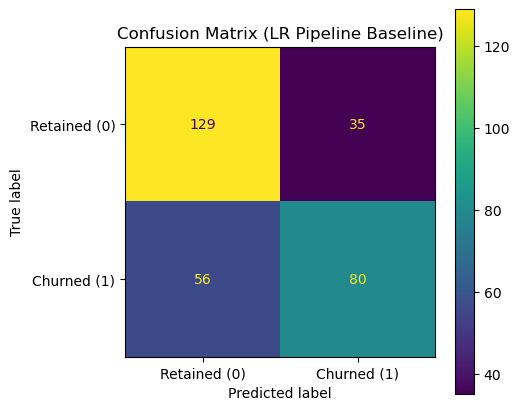

In [25]:
# Display confusion matrix
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_lr_baseline,
    labels=["Retained (0)", "Churned (1)"],
    title="Confusion Matrix (LR Pipeline Baseline)"
)

### Observations

- The workflow achieved an ROC-AUC of 0.736 on the test set.
- Precision and recall indicate moderate churn detection performance.
- Evaluation reflects the behavior of the entire workflow rather than the Logistic Regression model alone.
- Further improvements can be explored through workflow tuning and model comparison.

### Why Pipelines Matter in Production

In production systems, preprocessing and modeling should be treated as a single workflow rather than independent components.

This approach:

- ensures consistent transformations during training and prediction
- reduces implementation errors
- simplifies maintenance
- minimizes train-inference mismatches

Organizing machine learning workflows in this way improves reliability and reproducibility.

### Common Mistakes

Common workflow mistakes include:

- manually transforming data before prediction
- maintaining separate preprocessing and inference code paths
- forgetting to apply the same transformations during inference
- evaluating only the model while ignoring preprocessing

Pipelines help organize these operations into a single reusable workflow and reduce the likelihood of such errors.

## Key Takeaways

- Pipeline combines preprocessing and model training into a single reusable workflow.
- Training and prediction automatically use identical preprocessing logic.
- Pipeline enables the complete machine learning workflow to be evaluated as a single system.
- Organizing workflows improves maintainability, reproducibility, and reliability.
- Pipelines provide a foundation for safer training and inference workflows.

## Understanding Data Leakage

### What is Data Leakage?

Data leakage occurs when information from outside the training data influences the learning process.

As a result, evaluation metrics become overly optimistic and may not reflect real-world performance on unseen data.

---

### Why Data Leakage is Dangerous

A model affected by leakage may appear highly accurate during evaluation while performing poorly in production.

Leakage can lead to:

- unrealistic performance estimates
- poor generalization
- incorrect model selection
- unexpected failures after deployment

Preventing leakage is essential for building reliable machine learning systems.

---

### Common Sources of Data Leakage

Common sources of leakage include:

- scaling features before the train-test split
- imputing missing values before splitting
- encoding categorical variables before splitting
- performing feature selection using the entire dataset
- tuning hyperparameters using test data

Although these operations may appear harmless, they allow information from the test set to influence training.

---

### An Incorrect Workflow

A common mistake is to preprocess the entire dataset before performing the train-test split.

Because preprocessing statistics are computed using all observations, information from the test set indirectly influences training and introduces data leakage which results in train-test contamination and overly optimistic evaluation metrics.

```text
Raw Dataset
      │
      ▼
Preprocessing
(Imputation, Scaling, Encoding)
      │
      ▼
Train-Test Split
      │
      ▼
Model
      │
      ▼
Evaluation
```

#### Incorrect Workflow Example

The following workflow intentionally fits preprocessing on the entire dataset before splitting the data.

In [26]:
X = df.drop(columns=[TARGET_COL], axis=1)
y = df[TARGET_COL]

# Incorrect: fit preprocessing on the entire dataset
X_processed_incorrect = preprocessor.fit_transform(X)

# Train-test split after preprocessing (incorrect)
X_train_incorrect, X_test_incorrect, y_train_incorrect, y_test_incorrect = train_test_split(
    X_processed_incorrect,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Fit model on train data
lr_incorrect = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_incorrect.fit(
    X_train_incorrect,
    y_train_incorrect
)

# Predictions on test data
y_pred_incorrect = lr_incorrect.predict(
    X_test_incorrect
)

y_prob_incorrect = lr_incorrect.predict_proba(
    X_test_incorrect
)[:, 1]

In [27]:
# Evaluate
incorrect_metrics = evaluate_classification_model(
    y_true=y_test_incorrect,
    y_pred=y_pred_incorrect,
    y_prob=y_prob_incorrect
)

incorrect_metrics

,Metric,Score
0,ROC-AUC,0.737
1,Accuracy,0.693
2,Precision,0.690
3,Recall,0.588
4,F1-Score,0.635


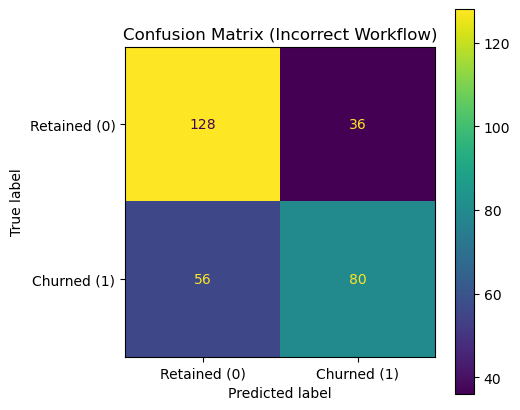

In [28]:
plot_confusion_matrix(
    y_true=y_test_incorrect,
    y_pred=y_pred_incorrect,
    labels=["Retained (0)", "Churned (1)"],
    title="Confusion Matrix (Incorrect Workflow)"
)

### Pipeline-Based Workflow

A safer approach is to perform the train-test split first and incorporate preprocessing into the Pipeline.

This ensures that preprocessing parameters are learned only from the training data and automatically applied to unseen observations.

```text
Raw Dataset
      │
      ▼
Train-Test Split
      │
      ▼
Pipeline
      │
 ┌─────────────────┐
 │ ColumnTransformer │
 └─────────────────┘
      │
      ▼
Logistic Regression
      │
      ▼
Evaluation
```

### Comparing the Two Workflows

Both workflows use the same preprocessing steps and Logistic Regression model.

The only difference is when preprocessing parameters are learned:

- the incorrect workflow fits preprocessing before the train-test split
- the pipeline workflow learns preprocessing parameters using only the training data

Comparing their performance illustrates the effect of data leakage.

In [29]:
workflow_leakage_comparison = compare_classification_metrics(
    metrics={
        "Incorrect Workflow": incorrect_metrics,
        "Pipeline Workflow": lr_pipeline_baseline_metrics,
    },
    reference="Incorrect Workflow"
)

workflow_leakage_comparison

,Metric,Incorrect Workflow,Pipeline Workflow,Δ Incorrect Workflow -> Pipeline Workflow
0,ROC-AUC,0.737,0.736,-0.001
1,Accuracy,0.693,0.697,0.004
2,Precision,0.690,0.696,0.006
3,Recall,0.588,0.588,0.000
4,F1-Score,0.635,0.637,0.002


### Observations

- Both workflows produce very similar performance metrics.
- In this dataset, preprocessing before the train-test split results in only minor differences in evaluation metrics.
- Data leakage does not always lead to dramatically inflated performance estimates.
- The impact of leakage depends on the dataset and preprocessing operations involved.
- Similar metrics do not imply that the workflow is correct.
- Even when the impact appears small, preprocessing should always be learned from the training data to avoid train-test contamination.
- Pipeline-based workflows provide a safer and more reliable approach for model development and evaluation.

### Why Pipelines Reduce Leakage Risk

Pipeline organizes preprocessing and modeling into a single workflow.

Because preprocessing parameters are learned only from the training data and automatically reused during prediction, the risk of train-test contamination is greatly reduced.

Pipelines therefore act as safety mechanisms rather than merely convenience tools, improving the reliability and reproducibility of machine learning workflows.

### Leakage Beyond Scaling

Data leakage is not limited to feature scaling.

Any operation that learns from the data should be fitted using only the training set.

Examples include:

- missing value imputation
- categorical encoding
- feature selection
- dimensionality reduction
- hyperparameter tuning

### Common Mistakes

Common causes of data leakage include:

- scaling features before the train-test split
- imputing missing values before splitting
- encoding categorical variables before splitting
- selecting features using the entire dataset
- tuning hyperparameters using test data
- repeatedly inspecting the test set during experimentation

These mistakes may produce misleading metrics and unrealistic expectations about production performance.

## Key Takeaways

- Preprocessing should be learned only from the training data.
- Performing preprocessing before the train-test split introduces data leakage.
- Data leakage does not always produce dramatically inflated metrics.
- The magnitude of leakage depends on the dataset and preprocessing operations involved.
- Similar metrics do not imply that a workflow is correct.
- Pipeline helps prevent train-test contamination by ensuring that preprocessing parameters are learned only from the training data.
- Pipelines should be viewed as safety mechanisms rather than merely convenience tools.

## Cross-Validation with Pipelines

### Why a Single Train-Test Split is Not Enough

A single train-test split provides only one estimate of model performance.

Because the split is influenced by randomness, the measured performance may vary depending on which observations happen to fall into the training and test sets.

Relying on a single split can therefore produce unstable conclusions.

Cross-validation provides a more robust estimate by evaluating the workflow across multiple train-test partitions.

---

### Cross-Validation as a Workflow Evaluation Strategy

Cross-validation repeatedly trains and evaluates the workflow on different subsets of the data.

Rather than relying on a single train-test split, the workflow is evaluated across multiple train-test partitions.

This reduces dependence on a particular split and produces more stable estimates of model performance.

---

### StratifiedKFold

For classification problems, maintaining class proportions across folds is important.

StratifiedKFold preserves the target distribution in each fold, ensuring that every fold contains representative examples from both classes.

This generally produces more reliable performance estimates for classification workflows.

---

### Why Preprocessing Must Occur Inside CV Folds

During cross-validation, preprocessing should be learned independently within each training fold.

If preprocessing is performed before cross-validation, information from validation folds may influence the learned transformations, introducing data leakage.

Using Pipeline together with cross-validation ensures that preprocessing and model training are repeated independently within each fold and that preprocessing parameters are learned only from the corresponding training data.

---

### Cross-Validation Workflow

When Pipeline and cross-validation are used together, preprocessing and model training are repeated independently within each fold.

This ensures that validation data remains unseen during training and that performance estimates better reflect real-world behavior.

```text
Fold 1:
Train
 ↓
Pipeline
(Preprocessing + Model)
 ↓
Validation

Fold 2:
Train
 ↓
Pipeline
(Preprocessing + Model)
 ↓
Validation

...

Average Performance Across Folds

### Cross-Validating the Pipeline

In [30]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    estimator=lr_pipeline_baseline,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring="roc_auc"
)

### Examining Fold-Level Performance

In [31]:
cv_results = pd.DataFrame({
    "Fold": range(1, len(cv_scores)+1),
    "ROC-AUC": cv_scores.round(3)
})

cv_results

,Fold,ROC-AUC
0,1,0.759
1,2,0.744
2,3,0.792
3,4,0.737
4,5,0.662


### Cross-Validation Summary

In [32]:
print("Mean ROC-AUC:", round(cv_scores.mean(),3))
print("Std ROC-AUC :", round(cv_scores.std(),3))

Mean ROC-AUC: 0.739
Std ROC-AUC : 0.043


### Observations

- The pipeline was evaluated across `5` different train-validation splits using StratifiedKFold.
- ROC-AUC scores varied across folds, ranging from `0.662` to `0.792`.
- The mean cross-validation ROC-AUC was `0.739`, which is close to the test-set ROC-AUC of `0.736` obtained from a single train-test split.
- The standard deviation of `0.043` indicates moderate variability across folds.
- Performance differences across folds highlight the uncertainty associated with relying on a single train-test split.
- Cross-validation provides a more robust estimate of workflow performance by evaluating the pipeline on multiple train-validation partitions.
- The evaluation reflects the behavior of the complete workflow rather than only the Logistic Regression model.

### Why We Evaluate the Workflow, Not Just the Model

Machine learning systems consist of both preprocessing and modeling components.

Cross-validation should therefore evaluate the complete workflow rather than only the underlying algorithm.

Using Pipeline together with cross-validation ensures that preprocessing is fitted independently within each fold, reducing the risk of data leakage.

As a result, cross-validation provides a more realistic estimate of how the entire workflow is expected to perform on unseen data.

---

### Common Mistakes

Common evaluation mistakes include:

- performing preprocessing before cross-validation
- relying on a single train-test split
- using ordinary `KFold` instead of `StratifiedKFold` for classification problems
- reporting only the best fold instead of average performance
- comparing models using different cross-validation strategies
- evaluating only the model while ignoring preprocessing

These practices can produce misleading performance estimates and unreliable model comparisons.

## Key Takeaways

- A single train-test split provides only one estimate of model performance.
- Cross-validation evaluates the workflow across multiple train-validation splits.
- `StratifiedKFold` preserves class proportions across folds and provides more reliable evaluation for classification problems.
- Preprocessing should occur inside each fold to avoid data leakage.
- Pipeline and cross-validation together evaluate the complete workflow rather than only the model.
- Mean cross-validation performance provides a more robust estimate of workflow performance than relying on a single train-test split.
- Variability across folds helps quantify the stability of the workflow.

## Hyperparameter Tuning with Pipelines

### Why Hyperparameters Matter

Machine learning models contain hyperparameters that control their learning behavior.

Unlike model parameters, hyperparameters are not learned from the data and must be specified before training.

Different hyperparameter values can lead to different performance characteristics.

Systematically exploring candidate values helps identify workflows that generalize better to unseen data.

---

### Why Manual Tuning Is Inefficient

Selecting hyperparameters through trial and error becomes increasingly difficult as the number of candidate configurations grows.

Manually training and evaluating models is:

- time consuming
- difficult to reproduce
- prone to human bias

A more reliable approach is to evaluate candidate configurations systematically using GridSearchCV.

---

### Hyperparameter Tuning and Cross-Validation

Hyperparameter tuning should not rely on a single train-test split.

Instead, each candidate configuration should be evaluated across multiple folds.

`GridSearchCV` evaluates each candidate workflow using cross-validation, providing a more robust basis for hyperparameter selection than a single train-test split.

---

### Why Tuning Should Occur Inside the Pipeline

Hyperparameter tuning should evaluate candidate workflows rather than only the underlying model.

Using `GridSearchCV` together with `Pipeline` ensures that preprocessing is performed correctly within each cross-validation fold, reducing the risk of data leakage.

As a result, candidate hyperparameter configurations are compared fairly and consistently.

### Defining the Cross-Validation Strategy

In [33]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

### Defining the Hyperparameter Grid

In [34]:
param_grid = { "model__C": [0.01, 0.1, 1, 10, 100] }

### Performing Grid Search

In [35]:
lr_pipeline_grid = GridSearchCV(
    estimator=lr_pipeline_baseline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    return_train_score=True,
    n_jobs=-1
)

lr_pipeline_grid.fit(X_train, y_train)
display(lr_pipeline_grid)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


### Best Hyperparameters

In [36]:
best_cv_roc_auc = lr_pipeline_grid.best_score_.round(3)

print(f"Best tuned LR CV ROC-AUC: {best_cv_roc_auc}")
print("Best C:", lr_pipeline_grid.best_params_["model__C"])

Best tuned LR CV ROC-AUC: 0.739
Best C: 1


The selected hyperparameters correspond to the workflow that achieved the highest mean cross-validation ROC-AUC across the evaluated candidate configurations.

### Examining Candidate Configurations

In [37]:
grid_search_results = pd.DataFrame(
    lr_pipeline_grid.cv_results_
).loc[:,["param_model__C", "mean_test_score", "mean_train_score"]].round(3)

grid_search_results

,param_model__C,mean_test_score,mean_train_score
0,0.01,0.726,0.738
1,0.10,0.737,0.753
2,1.00,0.739,0.754
3,10.00,0.739,0.754
4,100.00,0.739,0.754


### Observations

- Each candidate value of `C` was evaluated using 5-fold cross-validation.
- The configuration with the highest mean cross-validation ROC-AUC was selected.
- Candidate configurations exhibited similar performance, suggesting that Logistic Regression is relatively insensitive to the evaluated range of regularization strengths on this dataset.
- Cross-validation selected the best workflow using only the training data before the final evaluation on the unseen test set.

### Evaluating the Best Pipeline

In [38]:
# Best workflow selected by GridSearchCV
lr_pipeline_best = lr_pipeline_grid.best_estimator_

# Evaluate on the held-out test set
y_pred_lr_pipeline_best = lr_pipeline_best.predict(X_test)
y_prob_lr_pipeline_best = lr_pipeline_best.predict_proba(X_test)[:, 1]

In [39]:
# Metrics
lr_pipeline_best_metrics = evaluate_classification_model(
    y_true=y_test,
    y_pred=y_pred_lr_pipeline_best,
    y_prob=y_prob_lr_pipeline_best
)

lr_pipeline_best_metrics

,Metric,Score
0,ROC-AUC,0.736
1,Accuracy,0.697
2,Precision,0.696
3,Recall,0.588
4,F1-Score,0.637


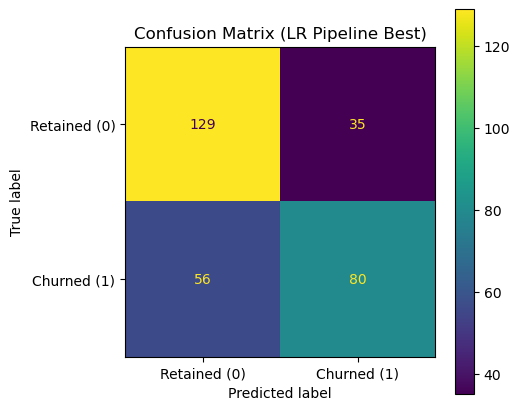

In [40]:
# Display confusion matrix
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_lr_pipeline_best,
    labels=["Retained (0)", "Churned (1)"],
    title="Confusion Matrix (LR Pipeline Best)"
)

### Comparing Baseline and Tuned Workflows

In [41]:
workflow_tuning_comparison = compare_classification_metrics(
    metrics={
        "Baseline Pipeline": lr_pipeline_baseline_metrics,
        "Tuned Pipeline": lr_pipeline_best_metrics,
    },
    reference="Baseline Pipeline"
)

workflow_tuning_comparison

,Metric,Baseline Pipeline,Tuned Pipeline,Δ Baseline Pipeline -> Tuned Pipeline
0,ROC-AUC,0.736,0.736,0.0
1,Accuracy,0.697,0.697,0.0
2,Precision,0.696,0.696,0.0
3,Recall,0.588,0.588,0.0
4,F1-Score,0.637,0.637,0.0


### Observations

- The workflow selected by GridSearchCV achieved the same performance as the baseline workflow on the held-out test set.
- Cross-validation identified `C = 1` as the best-performing regularization strength among the candidate values.
- The selected value matches the default Logistic Regression configuration used in the baseline workflow.
- This experiment demonstrates that hyperparameter tuning does not necessarily improve performance.
- Even when no improvement is observed, systematic tuning provides confidence that the baseline configuration is already near-optimal within the evaluated search space.

### Hyperparameter Tuning Assessment

Hyperparameter tuning systematically evaluates candidate workflows using cross-validation to identify configurations that generalize well to unseen data.

For this dataset, the default Logistic Regression configuration achieved the best cross-validation performance among the evaluated candidates.

Although tuning did not improve test-set performance, it confirmed that the baseline workflow was already well configured.

This highlights an important principle: hyperparameter tuning is valuable not only for discovering better configurations but also for validating that an existing workflow is already near-optimal.

Using `Pipeline` together with `GridSearchCV` enables fair, reproducible workflow comparison while reducing the risk of data leakage.

---

### Common Mistakes

Common tuning mistakes include:

- tuning hyperparameters using the test set
- relying on a single train-test split
- selecting the best model based on one fold
- performing preprocessing outside the pipeline
- searching unnecessarily large parameter grids
- optimizing only one metric without considering business requirements

These practices can produce unreliable performance estimates and lead to poor model selection.

## Key Takeaways

- Hyperparameters influence model behavior and should be selected systematically.
- `GridSearchCV` evaluates candidate workflows using cross-validation.
- Candidate configurations should be evaluated across multiple folds rather than a single train-test split.
- Hyperparameter tuning should optimize the complete workflow rather than only the underlying model.
- Using `Pipeline` during tuning helps prevent data leakage.
- Hyperparameter tuning may or may not improve performance, but it provides a reliable and reproducible basis for workflow optimization.
- The final model should be selected based on its performance on unseen test data rather than cross-validation results alone.